In [38]:
import os
import getpass
import json
import altair as alt

import pandas as pd
from sklearn.manifold import TSNE
import umap
import numpy as np
from ast import literal_eval
# create interactive plot with gradio
import gradio as gr
from gradio.components import scatter_plot
import requests
from itertools import islice
import hdbscan
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
reducer = umap.UMAP()
from sklearn.cluster import KMeans
alt.data_transformers.disable_max_rows()
# change the color palette to a list
import matplotlib.colors as mcolors
import shutil
from utils.utils import get_embedding_from_api, preprocess_text
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering


[nltk_data] Downloading package stopwords to /home/chris/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/chris/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/chris/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [3]:


# filter the dataframe to only include journals from the following list
# List of journals to include
journals_to_include = [
    "ACS Applied Materials & Interfaces",
    "ACS Nano",
    "Advanced Functional Materials",
    "Advanced Materials",
    "Angewandte Chemie",
    "Biology and Medicine",
    "Biomaterials",
    "Cell",
    "Clinical Cancer Research",
    "Frontiers in Nanotechnology",
    "Immunity",
    "International Journal of Nanomedicine",
    "Journal of Controlled Release",
    "Journal of Materials Chemistry B",
    "Matter",
    "Molecular Therapy",
    "Nano Letters",
    "Nano Micro Small",
    "Nano Research",
    "Nanomedicine",
    "Nanomedicine: Nanotechnology",
    "Nanoscale",
    "Nature",
    "Nature Biomedical Engineering",
    "Nature Cancer",
    "Nature Communications",
    "Nature Materials",
    "Nature Medicine",
    "Nature Nanotechnology",
    "NPG Asia Materials",
    "Pharmaceutics",
    "PNAS",
    "Science",
    "Science Advances",
    "Science Translational Medicine",
    "Scientific Reports",
    "Small"
]

# journals as small letters
journals_to_include = [journal.lower() for journal in journals_to_include]

# Exclusion criteria
keywords_exclusion = ["review", "not available"]



In [5]:
if not os.path.exists("embeddings_subset"):
    os.makedirs("embeddings_subset")

for filename in os.listdir("embeddings"):
    if filename.endswith(".json"):
        with open(f"embeddings/{filename}") as f:
            data = json.load(f)
            if data["journal"].lower() in journals_to_include and not any(keyword in data["title"].lower() for keyword in keywords_exclusion):
                # copy the file to the subset folder
                shutil.copy(f"embeddings/{filename}", f"embeddings_subset/{filename}")

In [6]:

# load the embeddings from the json files
folder_path = 'embeddings_subset'
json_files = [f for f in os.listdir(folder_path) if f.endswith('.json')]
# json_files = json_files[:1000]
data = {}

for file in json_files:
    with open(os.path.join(folder_path, file), 'r') as f:
        data[file] = json.load(f)

# data to dataframe
df = pd.DataFrame(data).T
df['size'] = 10
df['color'] = 'red'

# replace abstracts with the first abstract in the list if it is a list
df['abstract'] = df['abstract'].apply(lambda x: x[0] if isinstance(x, list) else x)

In [7]:

# # filter the dataframe to only include journals from the list
# df = df[df['journal'].str.lower().isin(journals_to_include)]

# # filter the dataframe to exclude titles with keywords from the exclusion list
# df = df[~df['title'].str.lower().str.contains('|'.join(keywords_exclusion))]

# store the embeddings in a numpy array
embeddings = np.array(df['embedding'].map(lambda x: np.array(x)))
embeddings = np.stack(embeddings)

In [10]:
# Determine the optimal number of clusters using the Elbow Method (optional)
# Sum of squared distances
ssd = []
K = range(1, 100)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(embeddings)
    ssd.append(kmeans.inertia_)

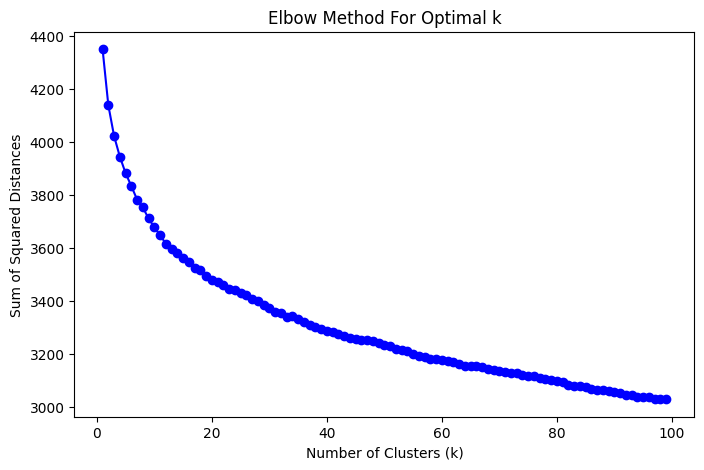

In [11]:
# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K, ssd, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method For Optimal k')
plt.show()

In [12]:
# Perform KMeans clustering

optimal_cluster_size = 18

kmeans = KMeans(n_clusters=optimal_cluster_size, random_state=42)
clusters = kmeans.fit_predict(embeddings)

Number of papers in each cluster:
0      989
1      705
2      249
3     1235
4      635
5      782
6      434
7      887
8      421
9      517
10     812
11     453
12     551
13     253
14     463
15     457
16     568
17     525
Name: count, dtype: int64


/tmp/ipykernel_5376/725204047.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='hsv')


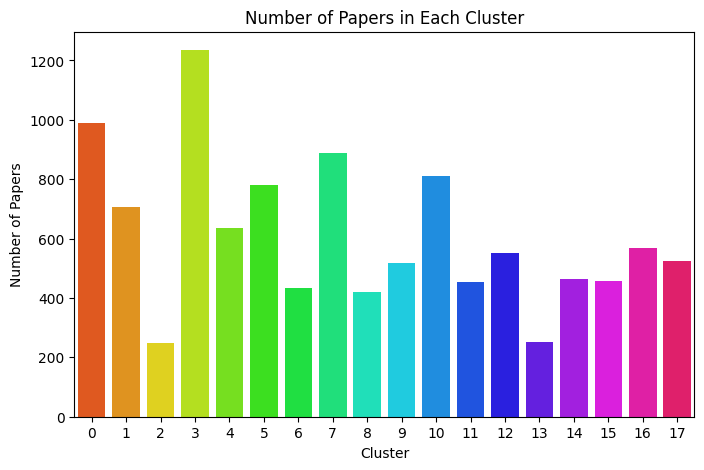

In [15]:
# Convert clusters to a pandas Series
clusters_series = pd.Series(clusters)

# Count the number of papers in each cluster
cluster_counts = clusters_series.value_counts().sort_index()

# Display the counts
print("Number of papers in each cluster:")
print(cluster_counts)

# Plot the cluster sizes
plt.figure(figsize=(8, 5))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='hsv')
plt.xlabel('Cluster')
plt.ylabel('Number of Papers')
plt.title('Number of Papers in Each Cluster')
plt.show()

In [16]:
# create a t-SNE object
tsne = TSNE(n_components=2, random_state=42, init='random', learning_rate=200, max_iter=1000)

# fit the t-SNE object to the embeddings
tsne_embeddings = tsne.fit_transform(embeddings)

# create new pandas df with old df added the tsne embeddings
df_tsne = df.copy()

df_tsne['tsne_x'] = tsne_embeddings[:, 0]
df_tsne['tsne_y'] = tsne_embeddings[:, 1]

In [17]:
clusters

array([14, 17, 17, ..., 15,  3, 14], dtype=int32)

In [19]:
## assign colors to the clusters
# create a color palette
color_palette = list(islice(mcolors.CSS4_COLORS.values(), optimal_cluster_size))

# assign colors to the clusters

df_tsne['color'] = [color_palette[cluster] for cluster in clusters]
# df_tsne['color'] = color_palette[clusters]

<Axes: xlabel='tsne_x', ylabel='tsne_y'>

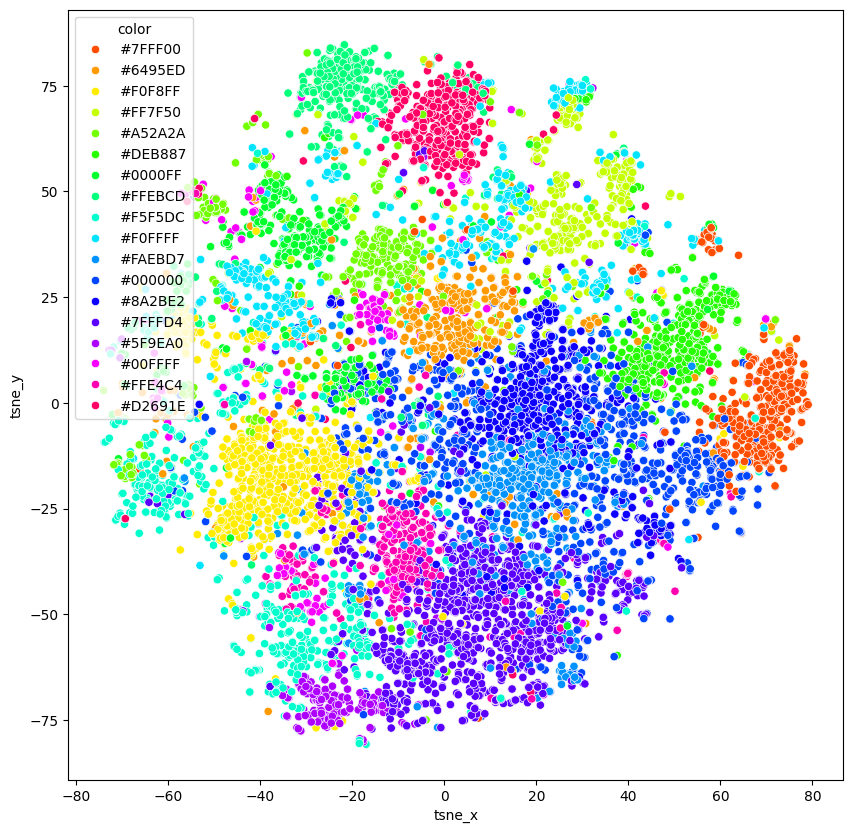

In [20]:
# plot the t-SNE embeddings
plt.figure(figsize=(10, 10))
sns.scatterplot(x='tsne_x', y='tsne_y', hue='color', data=df_tsne, palette='hsv')


/home/chris/Data/Projects/py_venv/nanopy310/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


<Axes: xlabel='umap_x', ylabel='umap_y'>

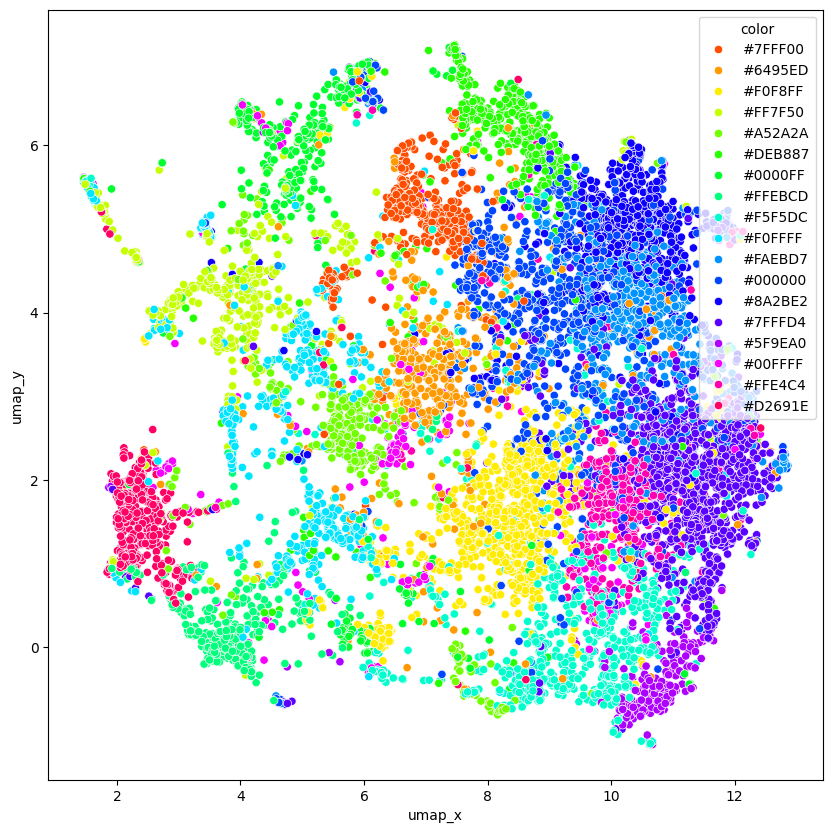

In [21]:
# create a UMAP object
reducer = umap.UMAP( n_components=2, random_state=42)

# fit the UMAP object to the embeddings
umap_embeddings = reducer.fit_transform(embeddings)

# create new pandas df with old df added the umap embeddings
df_umap = df.copy()

df_umap['umap_x'] = umap_embeddings[:, 0]
df_umap['umap_y'] = umap_embeddings[:, 1]

# assign colors to the clusters
df_umap['color'] = [color_palette[cluster] for cluster in clusters]

# plot the UMAP embeddings

plt.figure(figsize=(10, 10))
sns.scatterplot(x='umap_x', y='umap_y', hue='color', data=df_umap, palette='hsv')



## Trying a different clustering method

With K-means you have to predifine the number of clusters, which might not be ideal in the an unexplored data space. Instead, various unsupervised clustering techniques exist that can find an arbritrary amount of clusters

### HDBSCAN

In [22]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=10,  prediction_data=True, branch_detection_data=True, alpha=0.5, cluster_selection_method='leaf').fit(embeddings)

In [23]:
# number of clusters
n_clusters_ = len(set(clusterer.labels_)) - (1 if -1 in clusterer.labels_ else 0)

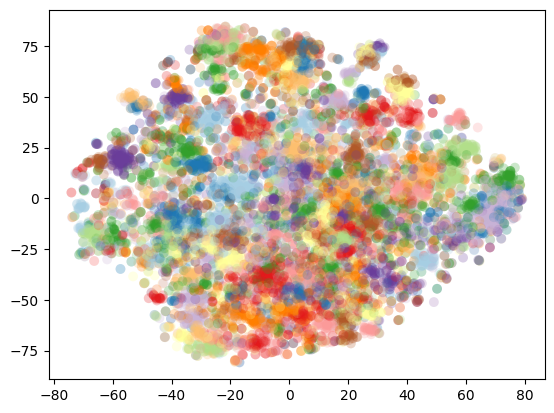

In [24]:
soft_clusters = hdbscan.all_points_membership_vectors(clusterer)
color_palette = sns.color_palette('Paired', n_clusters_)
cluster_colors = [color_palette[np.argmax(x)]
                  for x in soft_clusters]
plt.scatter(*tsne_embeddings.T, s=50, linewidth=0, c=cluster_colors, alpha=0.25)

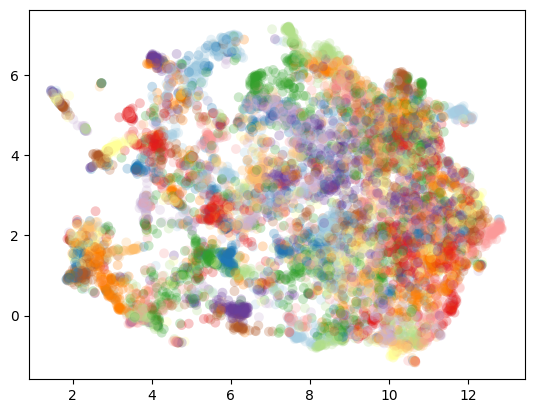

In [25]:
soft_clusters = hdbscan.all_points_membership_vectors(clusterer)
color_palette = sns.color_palette('Paired', n_clusters_)
cluster_colors = [color_palette[np.argmax(x)]
                  for x in soft_clusters]
plt.scatter(*umap_embeddings.T, s=50, linewidth=0, c=cluster_colors, alpha=0.25)

In [26]:
# repeating with larger clusters
clusterer = hdbscan.HDBSCAN(min_cluster_size=50,  prediction_data=True, branch_detection_data=True, alpha=0.5, cluster_selection_method='leaf').fit(embeddings)

# number of clusters
n_clusters_ = len(set(clusterer.labels_)) - (1 if -1 in clusterer.labels_ else 0)

soft_clusters = hdbscan.all_points_membership_vectors(clusterer)
color_palette = sns.color_palette('Paired', n_clusters_)
cluster_colors = [color_palette[np.argmax(x)]
                  for x in soft_clusters]


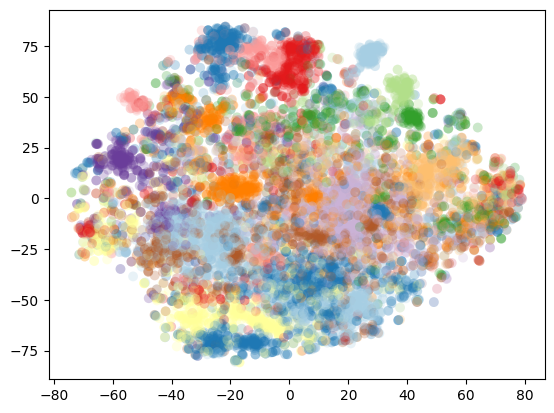

In [27]:
plt.scatter(*tsne_embeddings.T, s=50, linewidth=0, c=cluster_colors, alpha=0.25)

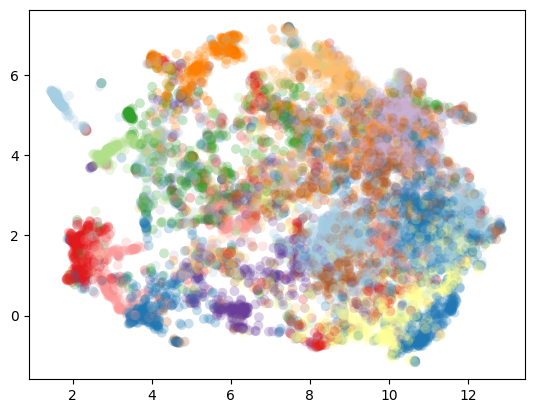

In [28]:
plt.scatter(*umap_embeddings.T, s=50, linewidth=0, c=cluster_colors, alpha=0.25)

### Hierarchical Clustering
Agglomerative Clustering: Useful for identifying nested clusters.

In [39]:

clustering = AgglomerativeClustering().fit(embeddings)
labels = clustering.labels_

In [44]:
color_palette = sns.color_palette('Paired', np.unique(labels).shape[0])
cluster_colors = [color_palette[label] for label in labels]

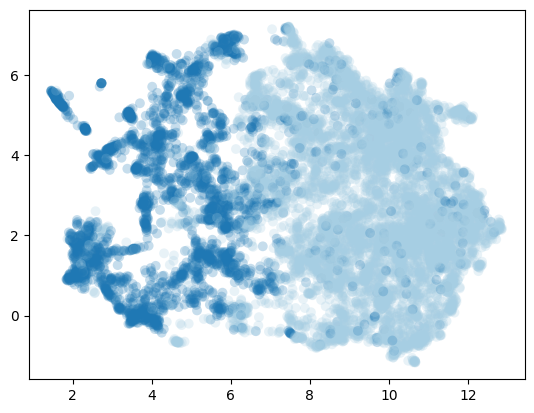

In [45]:
# use umapto display the clusters
plt.scatter(*umap_embeddings.T, s=50, linewidth=0, c=cluster_colors, alpha=0.25)

### Display 4 main parameters:

* Nanomedicine type (e.g. lipid nanoparticle, polymersome, gold nanoparticle etc.)
* Application (Cancer, cardiovascular, neurological, immunology etc.)
* Payload (siRNA, mRNA, protein etc.)
* Targeted cell type (Hepatocyte, neuron, macrophage etc.)

### 1. Similarity Analysis

Cosine Similarity:
* Compute Similarities: Use cosine similarity to measure the closeness between property embeddings and abstract embeddings.

In [46]:
nanomedice_properties = ["Nanomedicine type (e.g. lipid nanoparticle, polymersome, gold nanoparticle etc.)", 
                         "Application (Cancer, cardiovascular, neurological, immunology etc.)", "Payload (siRNA, mRNA, protein etc.)", 
                         "Targeted cell type (Hepatocyte, neuron, macrophage etc.)"]

In [47]:
cleaned_nanomedicine_properties = [preprocess_text(property_text) for property_text in nanomedice_properties]

In [48]:
cleaned_nanomedicine_properties

['nanomedicine type e g lipid nanoparticle polymersome gold nanoparticle etc',
 'application cancer cardiovascular neurological immunology etc',
 'payload sirna mrna protein etc',
 'targeted cell type hepatocyte neuron macrophage etc']

In [52]:
for property_text in cleaned_nanomedicine_properties:
    print(property_text)

    property_embedding, num_tokens = get_embedding_from_api(property_text)

    print(f"Number of tokens: {num_tokens}")
    print(property_embedding)
    similarities = cosine_similarity(np.array(property_embedding).reshape(1, -1), embeddings)

    # get the top 10 most similar papers
    top_10_indices = np.argsort(similarities[0])[::-1][:10]

    df_top_10 = df.iloc[top_10_indices]
    # print the top 10 titles
    print(df_top_10['title'])


nanomedicine type e g lipid nanoparticle polymersome gold nanoparticle etc
Number of tokens: 17
[0.0018253307789564133, 0.0353001169860363, 0.04537644982337952, -0.05349588766694069, -0.019658954814076424, -0.05533435940742493, -0.042542342096567154, 0.04809841141104698, 0.007822454907000065, 0.02334938757121563, 0.006704759784042835, 0.0026974619831889868, 0.014628690667450428, 0.03190317004919052, 0.08582601696252823, 0.01305921096354723, 0.018823903053998947, 0.0211600661277771, -0.019217979162931442, -0.023533884435892105, -0.05413341149687767, -0.023765090852975845, -0.033183544874191284, 0.0042254067957401276, 0.02847318723797798, 0.004174316301941872, -0.0012469175271689892, -0.007414869964122772, 0.026281775906682014, 0.022738274186849594, 0.005726969800889492, 0.016927149146795273, -0.03738652169704437, -0.016139093786478043, -0.006860234308987856, 0.002377789467573166, 0.025721853598952293, 0.033666983246803284, -0.009152497164905071, 0.025751346722245216, 0.05026612803339958

In [55]:
for property_text in cleaned_nanomedicine_properties:
    print(property_text)

    property_embedding, num_tokens = get_embedding_from_api(property_text)
    property_embedding = np.array(property_embedding).reshape(1, -1)
    # Create a list of the datasets
    datasets = [embeddings, property_embedding]
    embedding_dim = property_embedding.shape[1]
    print(embedding_dim)
    # Create a list of matching labels or identifiers for alignment
    # This step is crucial for aligning datasets based on shared features
    alignment_mapping = [{i: i for i in range(embedding_dim)} for _ in datasets]

    # Initialize the AlignedUMAP model
    aligned_mapper = umap.AlignedUMAP(n_neighbors=15, min_dist=0.1, n_components=2)
    # Fit and transform the datasets with relations
    aligned_embeddings = aligned_mapper.fit_transform(datasets, relations=alignment_mapping)

    # Unpack the transformed embeddings
    abstracts_aligned, properties_aligned = aligned_embeddings

    # Plot the embeddings
    plt.figure(figsize=(12, 8))

    # Plot abstracts
    plt.scatter(
        abstracts_aligned[:, 0],
        abstracts_aligned[:, 1],
        c='blue',
        label='Abstracts',
        alpha=0.5
    )

    # Plot properties
    plt.scatter(
        properties_aligned[:, 0],
        properties_aligned[:, 1],
        c='red',
        label='Properties',
        alpha=0.8,
        marker='X',
        s=100
    )

    plt.legend()
    plt.title(f'AlignedUMAP Projection of Abstracts and {property_text}')
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.show()

nanomedicine type e g lipid nanoparticle polymersome gold nanoparticle etc
1024


AssertionError: 